In [68]:
from typing import TypedDict, Annotated

from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
import langchain,langchain_groq,langgraph
from langgraph.graph import StateGraph, START, END

load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)


In [69]:
class TranslateState(TypedDict):
    input_text: str
    hindi_text: str


In [70]:
class OriginalState(TypedDict):
    user_input: str
    eng_output: str
    hindi_output: str


def generate(original_state: OriginalState):
    user_input = original_state["user_input"]
    eng_output = llm.invoke(user_input)
    return {"eng_output": eng_output.content}

def translate(parent_state: OriginalState):
    english_txt = parent_state["eng_output"]
    result = subgraph.invoke({"input_text": english_txt})
    return {"hindi_output": result["hindi_text"]}

def translate_to_hindi(translated_state: TranslateState):
    input_text = translated_state["input_text"]

    prompt = PromptTemplate(
        input_variables=["input_text"],
        template="""
Translate the following English text into natural, fluent Hindi.

Text:
{input_text}

Only return the Hindi translation. Do not add explanations.
"""
    )

    chain = prompt | llm
    hindi_output = chain.invoke({"input_text": input_text})

    return {"hindi_text": hindi_output.content}


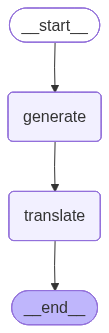

In [71]:

graph = StateGraph(OriginalState)
graph.add_node("generate",generate)
graph.add_node("translate",translate)
graph.add_edge(START,"generate")
graph.add_edge("generate","translate")
graph.add_edge("translate",END)

subgraph = StateGraph(TranslateState)
subgraph.add_node("translate_to_hindi",translate_to_hindi)
subgraph.add_edge(START,"translate_to_hindi")
subgraph.add_edge("translate_to_hindi",END)

app = graph.compile()
app

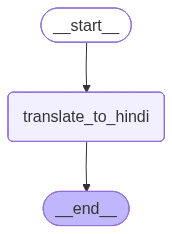

In [72]:
subgraph = subgraph.compile()
subgraph

In [73]:
result = app.invoke({"user_input":"Give me a business idea that can make millions"})
result["hindi_output"]

'**व्यवसाय विचार: “जन\u202fZ\u202fऔर मिलेनियल्स के लिए एआई‑संचालित व्यक्तिगत‑वित्त कोच”**\n\n---\n\n## 1. मुख्य अवधारणा  \nएक मोबाइल‑पहला, एआई‑आधारित व्यक्तिगत‑वित्त प्लेटफ़ॉर्म बनाइए जो युवा वयस्कों (उम्र\u202f18‑35) के लिए “कोच” की तरह काम करे। यह बजट बनाना, स्वचालित बचत, माइक्रो‑इन्वेस्टिंग, क्रेडिट‑बिल्डिंग टूल्स और व्यक्तिगत वित्तीय शिक्षा को एक संवादात्मक इंटरफ़ेस (चैटबॉट\u202f+\u202fवॉइस) के माध्यम से प्रदान करता है—जो एक भरोसेमंद दोस्त जैसा महसूस हो, न कि एक ठंडी स्प्रेडशीट।\n\n### यह लाखों तक क्यों पहुँच सकता है  \n| कारक | अंतर्दृष्टि |\n|------|-------------|\n| **बड़ा बाजार** | केवल यू.एस. में ही लगभग\u202f70\u202fमिलियन जन\u202fZ\u202fऔर मिलेनियल्स के पास $2\u202fट्रिलियन का खर्च करने योग्य आय है और वे पारंपरिक बैंकों से पर्याप्त सेवा नहीं प्राप्त कर रहे हैं। |\n| **दर्द बिंदु** | कम वित्तीय साक्षरता, “पे‑लेटर” संस्कृति, बचत में कठिनाई, और पुरानी वित्तीय संस्थानों पर अविश्वास। |\n| **तकनीकी तत्परता** | बड़े भाषा मॉडल (LLM), जेनरेटिव एआई और ओपन‑बैंकिंग API अब परिपक्व और किफ